In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
product_df=pd.read_csv('products_cleaned.csv')
order_df=pd.read_csv('orders_cleaned.csv')
order_item_df=pd.read_csv('order_items_cleaned.csv')
customer_df=pd.read_csv('customers_cleaned.csv')
geolocation_df=pd.read_csv('geolocation_cleaned.csv')
order_reviews_df=pd.read_csv('orders_reviews_cleaned.csv')

In [2]:
# product_df preprocessing

In [3]:
product_df.shape

(32951, 8)

In [4]:
order_df.shape

(94951, 9)

In [5]:
order_item_df.shape

(150000, 7)

In [6]:
customer_df.shape

(90000, 5)

In [7]:
order_reviews_df.shape

(91971, 5)

In [8]:
product_df.head()

,product_id,Category_name,sub_category_name,product_weight_g,brand,cost_price,selling_price,stock_availability
0,P00001,perfumery,Fragrances,225.0,Nivea,2200.0,2860.0,In Stock
1,P00002,art,General Merchandise,1000.0,Generic Global,110.0,140.0,In Stock
2,P00003,sports_leisure,General Merchandise,154.0,Generic Indian,14680.0,17170.0,In Stock
3,P00004,baby,Collectibles,371.0,Generic Indian,3890.0,4920.0,In Stock
4,P00005,housewares,Novelty Items,625.0,Generic Indian,12590.0,16220.0,In Stock


In [9]:
product_df.isnull().sum()

product_id            0
Category_name         0
sub_category_name     0
product_weight_g      0
brand                 0
cost_price            0
selling_price         0
stock_availability    0
dtype: int64

# Intial profit is S.P - C.P

In [10]:
product_df['profit']=product_df['selling_price']-product_df['cost_price']

In [11]:
product_df.head()

,product_id,Category_name,sub_category_name,product_weight_g,brand,cost_price,selling_price,stock_availability,profit
0,P00001,perfumery,Fragrances,225.0,Nivea,2200.0,2860.0,In Stock,660.0
1,P00002,art,General Merchandise,1000.0,Generic Global,110.0,140.0,In Stock,30.0
2,P00003,sports_leisure,General Merchandise,154.0,Generic Indian,14680.0,17170.0,In Stock,2490.0
3,P00004,baby,Collectibles,371.0,Generic Indian,3890.0,4920.0,In Stock,1030.0
4,P00005,housewares,Novelty Items,625.0,Generic Indian,12590.0,16220.0,In Stock,3630.0


In [12]:
product_df.duplicated().sum()

0

In [13]:
# order_item_df preprocessing

In [14]:
order_item_df.isnull().sum()

order_item_id    0
order_id         0
quantity         0
product_id       0
unit_price       0
discount(%)      0
shipping_cost    0
dtype: int64

In [15]:
order_item_df.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost
0,OI000001,O00001,1.0,P28355,7020.0,6.54,713.72
1,OI000002,O00002,1.0,P04408,7590.0,20.56,1212.02
2,OI000003,O00002,1.0,P14887,14360.0,24.67,1478.39
3,OI000004,O00003,1.0,P02014,1530.0,12.06,155.12
4,OI000005,O00003,1.0,P27255,1560.0,10.51,188.03


In [16]:
order_item_df['quantity'].unique()

array([1.])

In [17]:
order_item_df['discounted_price']=order_item_df['unit_price']*(order_item_df['discount(%)']/100)

In [18]:
order_item_df.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,discounted_price
0,OI000001,O00001,1.0,P28355,7020.0,6.54,713.72,459.108
1,OI000002,O00002,1.0,P04408,7590.0,20.56,1212.02,1560.504
2,OI000003,O00002,1.0,P14887,14360.0,24.67,1478.39,3542.612
3,OI000004,O00003,1.0,P02014,1530.0,12.06,155.12,184.518
4,OI000005,O00003,1.0,P27255,1560.0,10.51,188.03,163.956


In [19]:
order_item_df['final_cost']=order_item_df['unit_price']-order_item_df['discounted_price']+order_item_df['shipping_cost']

In [20]:
order_item_df.shape

(150000, 9)

In [21]:
order_reviews_df.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_message',
       'review_date'],
      dtype='object')

In [22]:
product_order_item_df=order_item_df.copy()

In [23]:
# Joining order_item_df and product_df

In [24]:
product_order_item_df=pd.merge(order_item_df,product_df,on='product_id',how='inner')

In [25]:
product_order_item_df=product_order_item_df.merge(order_df,on='order_id',how='left')


In [26]:
product_order_item_df=product_order_item_df.merge(customer_df,on='customer_id',how='left')

In [27]:
review_agg=order_reviews_df.groupby('order_id').agg(
    {'review_score':'mean',
     'review_id':'count',
     'review_comment_message':'first',
     'review_date':'first'}).reset_index()

In [28]:
product_order_item_df=product_order_item_df.merge(review_agg,on='order_id',how='left')

In [29]:
product_order_item_df['Total_profit']=product_order_item_df['profit']-product_order_item_df['discounted_price']+product_order_item_df['shipping_cost']

In [30]:
product_order_item_df.columns

Index(['order_item_id', 'order_id', 'quantity', 'product_id', 'unit_price',
       'discount(%)', 'shipping_cost', 'discounted_price', 'final_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'profit',
       'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'review_score', 'review_id',
       'review_comment_message', 'review_date', 'Total_profit'],
      dtype='object')

In [31]:
product_order_item_df.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,discounted_price,final_cost,Category_name,...,order_estimated_delivery_date,customer_zip_code,gender,age_group,customer_segment,review_score,review_id,review_comment_message,review_date,Total_profit
0,OI000001,O00001,1.0,P28355,7020.0,6.54,713.72,459.108,7274.612,sports_leisure,...,2025-01-03,413514.0,Male,46-55,Loyal,1.0,1.0,Item arrived damaged.,2025-04-05,1944.612
1,OI052628,O23303,1.0,P28355,7020.0,35.70,713.72,2506.140,5227.580,sports_leisure,...,2021-04-28,758013.0,Male,18-25,New,1.0,1.0,Disappointed with the quality.,2022-11-01,-102.420
2,OI098097,O43535,1.0,P28355,7020.0,36.58,570.97,2567.916,5023.054,sports_leisure,...,2025-01-30,262552.0,Female,26-35,New,4.0,1.0,Excellent quality and service.,2025-01-15,-306.946
3,OI000002,O00002,1.0,P04408,7590.0,20.56,1212.02,1560.504,7241.516,sports_leisure,...,2023-10-31,523230.0,Male,36-45,New,5.0,1.0,Great product and quick delivery.,2023-05-13,1051.516
4,OI054009,O23922,1.0,P04408,7590.0,32.15,808.02,2440.185,5957.835,sports_leisure,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-232.165


In [32]:
product_order_item_df['review_date'].fillna('No Review',inplace=True)

In [33]:
product_order_item_df.isnull().sum()

order_item_id                        0
order_id                             0
quantity                             0
product_id                           0
unit_price                           0
discount(%)                          0
shipping_cost                        0
discounted_price                     0
final_cost                           0
Category_name                        0
sub_category_name                    0
product_weight_g                     0
brand                                0
cost_price                           0
selling_price                        0
stock_availability                   0
profit                               0
customer_id                       7615
order_status                      7615
payment_type                      7615
order_purchase_timestamp          7615
order_approved_at                 7615
order_delivered_shipping_date     7615
order_delivered_customer_date    12030
order_estimated_delivery_date     7615
customer_zip_code        

In [34]:
# Remove unmatched orders
product_order_item_df = product_order_item_df[product_order_item_df['customer_id'].notna()]
# i removed records with missing custoimers id because they represent incomplete transaction and cannot be used for customer level anaysis or modeling
# Reviews
product_order_item_df['review_score'] = product_order_item_df['review_score'].fillna(0)
product_order_item_df['review_id'] = product_order_item_df['review_id'].fillna(0)
product_order_item_df['review_comment_message'] = product_order_item_df['review_comment_message'].fillna("No Review")
product_order_item_df=product_order_item_df[product_order_item_df['order_delivered_customer_date'].notna()]

In [35]:
product_order_item_df.isnull().sum()

order_item_id                    0
order_id                         0
quantity                         0
product_id                       0
unit_price                       0
discount(%)                      0
shipping_cost                    0
discounted_price                 0
final_cost                       0
Category_name                    0
sub_category_name                0
product_weight_g                 0
brand                            0
cost_price                       0
selling_price                    0
stock_availability               0
profit                           0
customer_id                      0
order_status                     0
payment_type                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_shipping_date    0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_zip_code                0
gender                           0
age_group                        0
customer_segment    

In [36]:
# converting date columns

In [37]:
product_order_item_df['Order_date']=pd.to_datetime(product_order_item_df['order_purchase_timestamp'])

In [38]:
product_order_item_df['Order_Month']=pd.to_datetime(product_order_item_df['order_purchase_timestamp']).dt.month

In [39]:
product_order_item_df['order_Year']=pd.to_datetime(product_order_item_df['order_purchase_timestamp']).dt.year

In [40]:
product_order_item_df['order_day_of_week']=pd.to_datetime(product_order_item_df['order_purchase_timestamp']).dt.dayofweek

In [41]:
# delivery_time
product_order_item_df['order_purchase_timestamp']=pd.to_datetime(product_order_item_df['order_purchase_timestamp'])
product_order_item_df['order_delivered_customer_date']=pd.to_datetime(product_order_item_df['order_delivered_customer_date'])
product_order_item_df['order_estimated_delivery_date']=pd.to_datetime(product_order_item_df['order_estimated_delivery_date'])
product_order_item_df['delivery_time']=(product_order_item_df['order_delivered_customer_date']-product_order_item_df['order_purchase_timestamp']).dt.days

In [42]:
median_time = product_order_item_df['delivery_time'].median()

product_order_item_df['late_delivery'] = product_order_item_df['delivery_time'].apply(
    lambda x: 1 if x > median_time else 0
)

In [43]:
product_order_item_df['late_delivery'].value_counts()

0    70940
1    67030
Name: late_delivery, dtype: int64

In [44]:
product_order_item_df.head()

,order_item_id,order_id,quantity,product_id,unit_price,discount(%),shipping_cost,discounted_price,final_cost,Category_name,...,review_id,review_comment_message,review_date,Total_profit,Order_date,Order_Month,order_Year,order_day_of_week,delivery_time,late_delivery
0,OI000001,O00001,1.0,P28355,7020.0,6.54,713.72,459.108,7274.612,sports_leisure,...,1.0,Item arrived damaged.,2025-04-05,1944.612,2024-11-04,11,2024,0,120,1
1,OI052628,O23303,1.0,P28355,7020.0,35.70,713.72,2506.140,5227.580,sports_leisure,...,1.0,Disappointed with the quality.,2022-11-01,-102.420,2021-04-16,4,2021,4,37,0
2,OI098097,O43535,1.0,P28355,7020.0,36.58,570.97,2567.916,5023.054,sports_leisure,...,1.0,Excellent quality and service.,2025-01-15,-306.946,2025-01-26,1,2025,6,34,0
3,OI000002,O00002,1.0,P04408,7590.0,20.56,1212.02,1560.504,7241.516,sports_leisure,...,1.0,Great product and quick delivery.,2023-05-13,1051.516,2023-09-01,9,2023,4,34,0
5,OI072928,O32318,1.0,P04408,7590.0,26.19,969.62,1987.821,6571.799,sports_leisure,...,1.0,Delivery was delayed and support was unhelpful.,2022-05-29,381.799,2024-06-21,6,2024,4,5,0


In [45]:
product_order_item_df.shape

(137970, 40)

In [46]:
product_order_item_df.dtypes

order_item_id                            object
order_id                                 object
quantity                                float64
product_id                               object
unit_price                              float64
discount(%)                             float64
shipping_cost                           float64
discounted_price                        float64
final_cost                              float64
Category_name                            object
sub_category_name                        object
product_weight_g                        float64
brand                                    object
cost_price                              float64
selling_price                           float64
stock_availability                       object
profit                                  float64
customer_id                              object
order_status                             object
payment_type                             object
order_purchase_timestamp         datetim

In [47]:
# product analysis

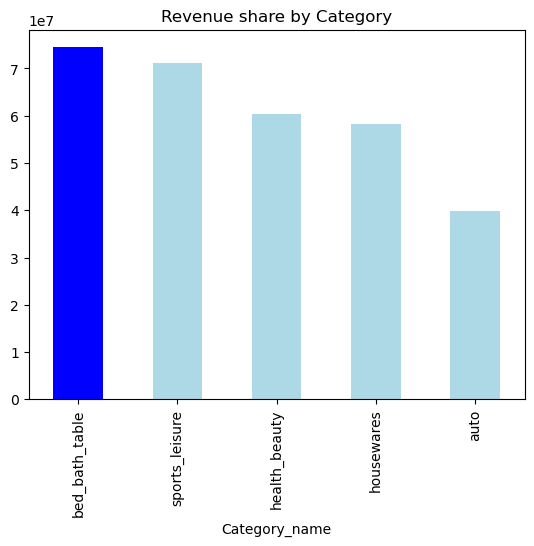

In [48]:
#1. what is the total revenue generated by each product category?
data=product_order_item_df.groupby('Category_name')['final_cost'].sum().sort_values(ascending=False).head(5)
colors=['blue']+['lightblue']*(len(data)-1)
data.plot(kind='bar',color=colors)
plt.title('Revenue share by Category')
plt.show()

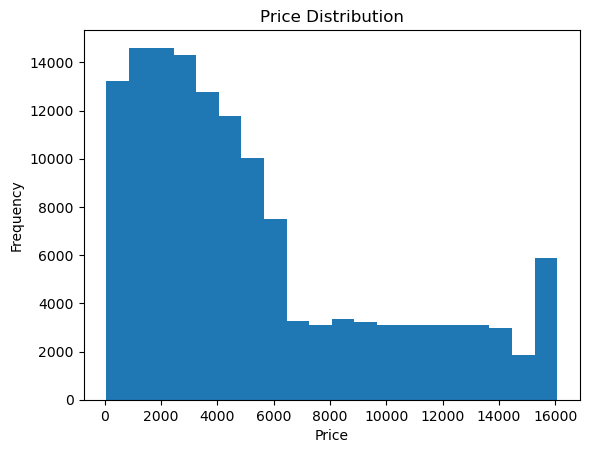

In [49]:
# 2.How do product prices distributed?
plt.hist(product_order_item_df['unit_price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

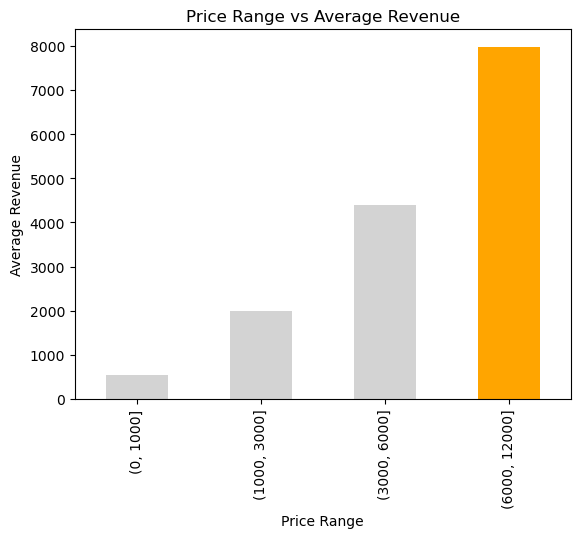

In [50]:
# 3. do higher priced products generates more revenue?
product_order_item_df['price_range'] = pd.cut(product_order_item_df['unit_price'], bins=[0,1000,3000,6000,12000])

# Group data
temp = product_order_item_df.groupby('price_range')['final_cost'].mean()

# Find max value
max_value = temp.max()

# Create colors (highlight max)
colors = ['orange' if v == max_value else 'lightgray' for v in temp]

# Plot
plt.figure()
temp.plot(kind='bar', color=colors)
plt.title('Price Range vs Average Revenue')
plt.xlabel('Price Range')
plt.ylabel('Average Revenue')
plt.show()

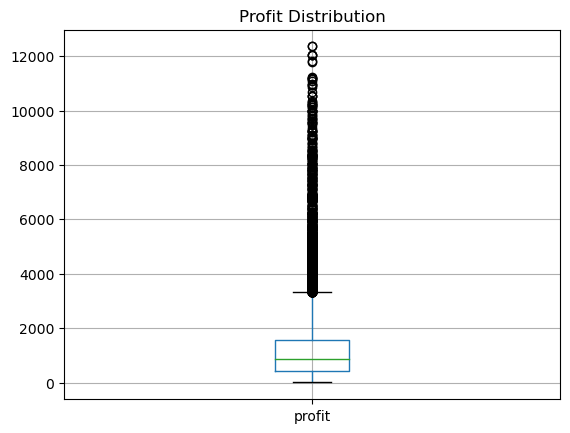

In [51]:
# 4. how does profit vary across products?
product_order_item_df.boxplot(column='profit')
plt.title('Profit Distribution')
plt.show()

In [52]:
# customer Analysis

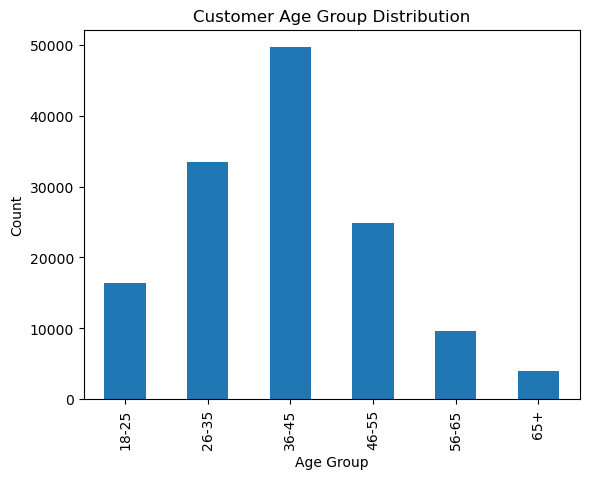

In [53]:
#1.what is the distribution of customers by age group?
order = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

product_order_item_df['age_group'].value_counts().reindex(order).plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

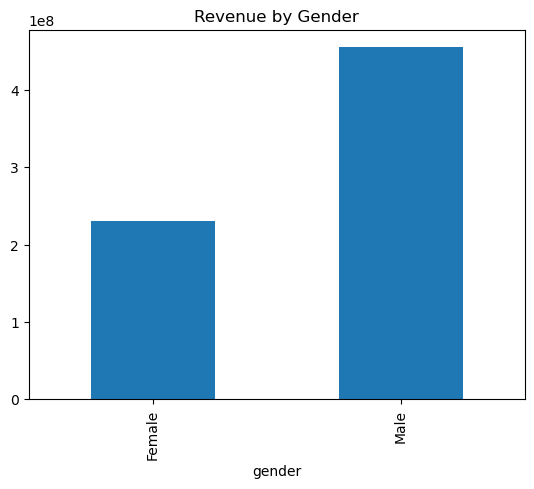

In [54]:
# 2.which gender contributes more to revenue?
product_order_item_df.groupby('gender')['final_cost'].sum().plot(kind='bar')
plt.title('Revenue by Gender')
plt.show()

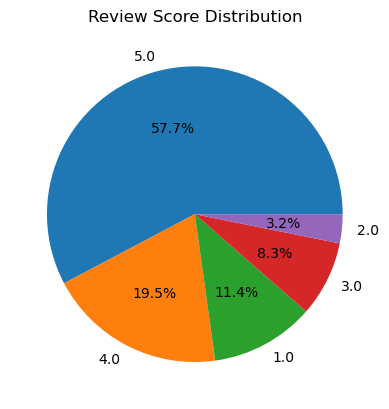

In [55]:
# 3.what is the distribution of customer rating?
product_order_item_df['review_score'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Review Score Distribution')
plt.ylabel('')
plt.show()

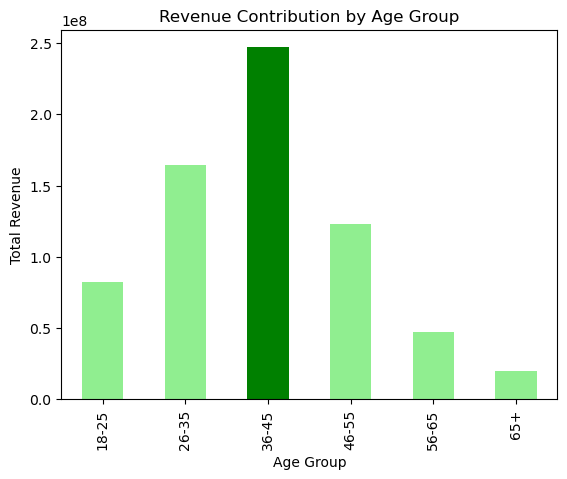

In [56]:
# 4.Which age group contributes more to revenue?
order = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

temp = product_order_item_df.groupby('age_group')['final_cost'].sum().reindex(order)

# Highlight highest
max_value = temp.max()
colors = ['green' if v == max_value else 'lightgreen' for v in temp]

plt.figure()
temp.plot(kind='bar', color=colors)
plt.title('Revenue Contribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.show()

In [57]:
# delivery analysis

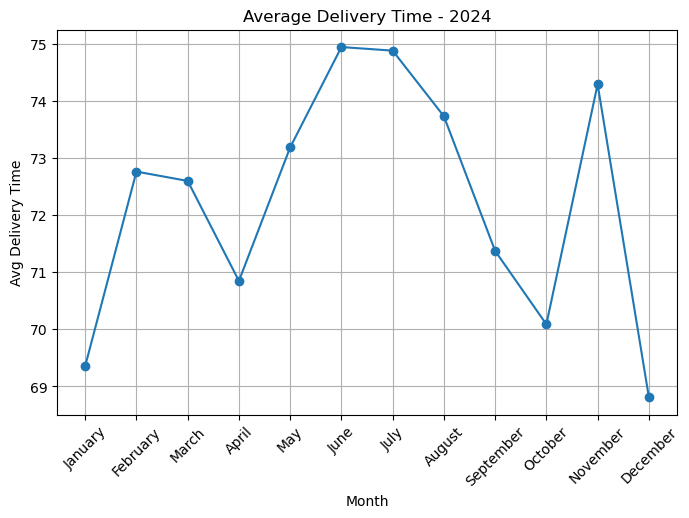

In [58]:
# 1. How does average delivery time change across months in 2024, and are there any months with delays that need improvement?
# Convert to datetime 
product_order_item_df['order_purchase_timestamp'] = pd.to_datetime(product_order_item_df['order_purchase_timestamp'])

# Filter only 2024 data
product_order_item_df = product_order_item_df[product_order_item_df['order_purchase_timestamp'].dt.year == 2024]

# Extract month name
product_order_item_df['month'] = product_order_item_df['order_purchase_timestamp'].dt.month_name()

# Order months correctly
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

product_order_item_df['month'] = pd.Categorical(product_order_item_df['month'], categories=month_order, ordered=True)

# Group by month (average delivery time)
data = product_order_item_df.groupby('month')['delivery_time'].mean()

# Plot line chart
plt.figure(figsize=(8,5))
plt.plot(data.index, data.values, marker='o')

plt.title('Average Delivery Time - 2024')
plt.xlabel('Month')
plt.ylabel('Avg Delivery Time')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [59]:
# 2.what percentage of orders are late deliveries?
product_order_item_df['late_delivery'].value_counts()

0    17085
1    15965
Name: late_delivery, dtype: int64

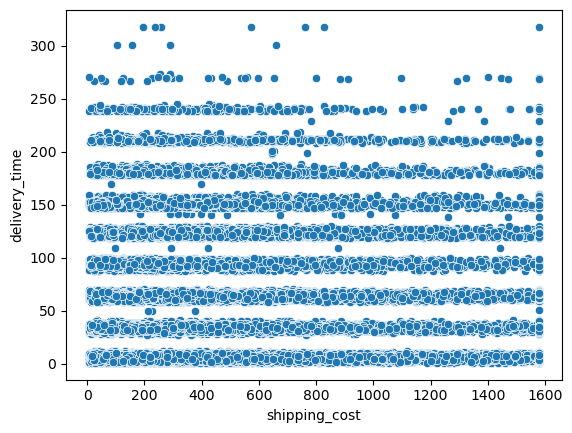

In [60]:
# 3.Does shipping cost affect delivery time?
sns.scatterplot(x='shipping_cost',y='delivery_time',data=product_order_item_df)
plt.show()

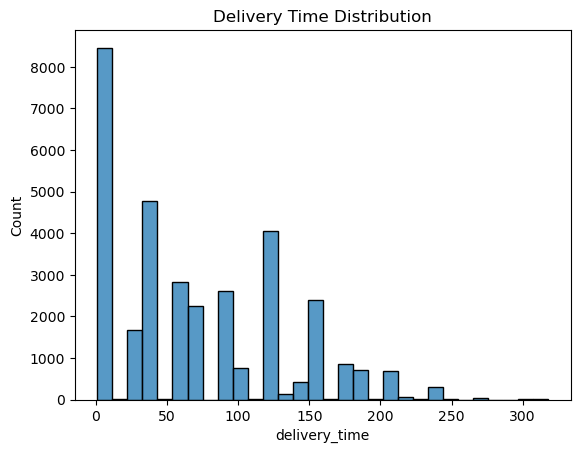

In [61]:
# 4. what is the distribution of delivery time?
sns.histplot(product_order_item_df['delivery_time'],bins=30)
plt.title("Delivery Time Distribution")
plt.show()

In [62]:
# product analysis

In [63]:
import pandas as pd

# Population data
population_df = product_order_item_df[['final_cost']].dropna()

# Sample data (size = 30)

sample_df = population_df.sample(n=30, random_state=42)

In [64]:
from scipy.stats import skew, kurtosis

print("SUMMARY STATISTICS OF POPULATION")
print(population_df['final_cost'].describe().round(2))

print("Skewness:", round(skew(population_df['final_cost']), 2))
print("Kurtosis:", round(kurtosis(population_df['final_cost']), 2))
print("Median:", population_df['final_cost'].median())
print("Mode:", population_df['final_cost'].mode()[0])

SUMMARY STATISTICS OF POPULATION
count    33050.00
mean      4940.67
std       3768.82
min         48.83
25%       2001.97
50%       3968.26
75%       6710.35
max      16163.74
Name: final_cost, dtype: float64
Skewness: 0.91
Kurtosis: -0.1
Median: 3968.265
Mode: 11771.813999999998


In [65]:
print("\nSUMMARY STATISTICS OF SAMPLE DATA")
print(sample_df['final_cost'].describe().round(2))
print("Skewness:", round(skew(sample_df['final_cost']), 2))
print("Kurtosis:", round(kurtosis(sample_df['final_cost']), 2))
print("Median:", sample_df['final_cost'].median())
print("Mode:", sample_df['final_cost'].mode()[0])


SUMMARY STATISTICS OF SAMPLE DATA
count       30.00
mean      4375.97
std       3663.14
min        125.11
25%       1517.61
50%       3345.58
75%       5979.73
max      13382.03
Name: final_cost, dtype: float64
Skewness: 1.07
Kurtosis: 0.22
Median: 3345.579
Mode: 125.11


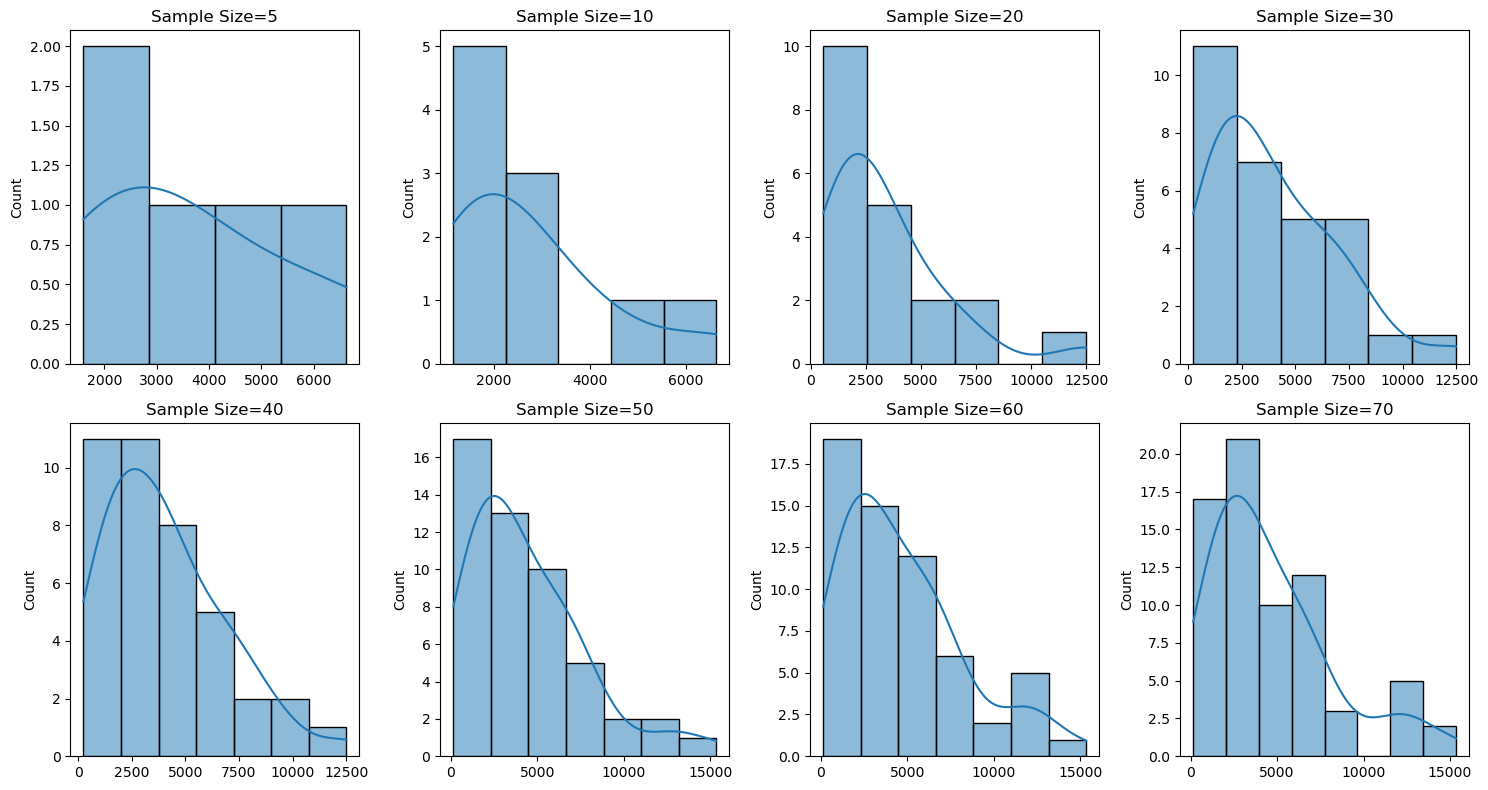

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# create population dataframe (use your column)
population_df = product_order_item_df[['final_cost']].dropna()

num = [5,10,20,30,40,50,60,70]

data_s = []
data_s_mean = []

fig, ax = plt.subplots(2,4,figsize=(15,8))
k = 0

for i in num:
    sample_df = population_df.sample(n=i, random_state=42, replace=True)
    data_s.append(sample_df['final_cost'].tolist())
    data_s_mean.append(sample_df['final_cost'].mean())
k = 0

for i in range(2):
    for j in range(4):
        sns.histplot(data_s[k], kde=True, ax=ax[i,j])
        ax[i,j].set_title("Sample Size=" + str(len(data_s[k])))
        k += 1

plt.tight_layout()
plt.show()

In [67]:
sample_df = population_df.sample(n=30, random_state=42, replace=True)

print("-----Mean Value------")
print("Sample mean:", round(sample_df["final_cost"].mean(), 2))
print("Population mean:", round(population_df["final_cost"].mean(), 2))

print("-----Skewness------")
print("Sample Skewness:", round(sample_df["final_cost"].skew(), 2))
print("Population Skewness:", round(population_df["final_cost"].skew(), 2))

print("-----Kurtosis------")
print("Sample Kurtosis:", round(sample_df["final_cost"].kurtosis(), 2))
print("Population Kurtosis:", round(population_df["final_cost"].kurtosis(), 2))

-----Mean Value------
Sample mean: 3933.08
Population mean: 4940.67
-----Skewness------
Sample Skewness: 1.09
Population Skewness: 0.91
-----Kurtosis------
Sample Kurtosis: 1.11
Population Kurtosis: -0.1


In [68]:
sample_df = pd.DataFrame()

for i in range(0,10):
    sample_df["sample"+str(i)] = population_df['final_cost'].sample(n=30, random_state=i).reset_index(drop=True)
sample_df

,sample0,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9
0,11759.130,3032.090,3697.120,999.201,1220.824,861.778,2216.334,4602.054,7808.680,13010.325
1,16163.745,4900.337,5026.356,5616.848,2749.774,2052.765,1345.706,5043.212,6471.964,3095.900
2,7463.406,4806.676,4469.632,3445.952,2797.076,4190.798,5979.157,5458.335,5567.384,10162.604
3,2100.880,4277.285,2308.974,2038.590,12438.026,901.883,2715.226,3956.844,1109.594,629.132
4,7138.804,2201.750,11749.936,5180.020,10783.757,4876.095,5320.328,3913.478,2348.246,8114.574
5,2251.160,3376.300,499.397,5553.630,2434.956,4655.176,241.284,306.150,4685.724,12183.813
6,3996.155,681.850,10311.452,6458.030,15818.240,1102.536,12960.100,306.162,3475.572,3581.358
7,1924.656,5306.228,5185.160,1121.430,11771.814,3700.100,4484.517,2206.614,1185.385,3885.210
8,10003.462,8405.920,5092.726,386.908,2761.520,11204.850,6469.950,3329.262,12541.242,141.422
9,4471.398,2946.738,2536.896,540.734,1399.012,9267.068,3624.532,9684.926,1054.546,13348.565


In [69]:
c_names = sample_df.columns
c_mean = []

for i in c_names:
    c_mean.append(sample_df[i].mean())

means = pd.DataFrame()
means.insert(0,"C_name",c_names)
means.insert(1,"mean",c_mean)

means

,C_name,mean
0,sample0,5185.121333
1,sample1,4248.746300
2,sample2,5306.772167
3,sample3,4152.058833
4,sample4,5042.530300
5,sample5,5285.578500
6,sample6,6181.926667
7,sample7,4670.251567
8,sample8,5674.203333
9,sample9,6099.687433


In [70]:
means_std = means['mean'].std()
means_std

693.1074411374495

In [71]:
import math

population_df['final_cost'].std() / math.sqrt(30)

688.090066292075

In [72]:
from scipy import stats
import math


# Population
population = product_order_item_df['final_cost'].dropna()

# Sample (n=30)
sample = population.sample(n=30, random_state=42)


# Statistics
mean_sample = sample.mean()
std_sample = sample.std() 
std_pop = population.std()
n = 30
mu = 3500


# Standard Error
se = std_pop / math.sqrt(n)


#  Z-score
z_score = (mean_sample - mu) / se

#  P-value (right-tailed)
p_value = 1 - stats.norm.cdf(z_score)

# Critical Z value
alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha)

print(f"Sample Mean: {mean_sample:.2f}")
print(f"Sample Std Dev: {std_sample:.2f}")
print(f"Population Std Dev: {std_pop:.2f}") 
print(f"Z-score: {z_score:.4f}")
print(f"Critical Z: {z_critical:.4f}")
print(f"P-value: {p_value:.4f}")


if p_value < alpha:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: Average revenue is significantly greater than ₹3500")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: Average revenue is not significantly greater than ₹3500")

Sample Mean: 4375.97
Sample Std Dev: 3663.14
Population Std Dev: 3768.82
Z-score: 1.2731
Critical Z: 1.6449
P-value: 0.1015

Result: Fail to Reject Null Hypothesis
Conclusion: Average revenue is not significantly greater than ₹3500


In [73]:
product_order_item_df['high_revenue'] = product_order_item_df['final_cost'] > 5000

# Calculate probability
prob_high = product_order_item_df['high_revenue'].sum() / len(product_order_item_df)

print("Probability of high revenue (>5000):", round(prob_high, 3))

Probability of high revenue (>5000): 0.39


In [74]:
# Create revenue groups
product_order_item_df['revenue_group'] = pd.cut(product_order_item_df['final_cost'],
                            bins=[0, 3000, 6000, product_order_item_df['final_cost'].max()],
                            labels=['Low', 'Medium', 'High'])


In [75]:
table = pd.crosstab(product_order_item_df['Category_name'], product_order_item_df['revenue_group'])
table

revenue_group,Low,Medium,High
Category_name,,,
agro_industry_and_commerce,35,44,27
air_conditioning,48,40,53
art,23,9,20
arts_and_craftmanship,2,4,9
audio,0,0,6
...,...,...,...
stationery,1506,388,0
tablets_printing_image,4,4,5
telephony,358,353,439


In [76]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", round(chi2,2))
print("P-value:", round(p,4))
alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Chi-square value: 6235.0
P-value: 0.0
Reject Null Hypothesis


# customer analysis

In [77]:
import pandas as pd

# Population data (Customer Satisfaction)
population_df = product_order_item_df[['review_score']].dropna()

# Sample data (size = 30)
sample_df = population_df.sample(n=30, random_state=42)

In [78]:
from scipy.stats import skew, kurtosis

print("SUMMARY STATISTICS OF POPULATION")
print(population_df['review_score'].describe().round(2))

print("Skewness:", round(skew(population_df['review_score']), 2))
print("Kurtosis:", round(kurtosis(population_df['review_score']), 2))
print("Median:", population_df['review_score'].median())
print("Mode:", population_df['review_score'].mode()[0])

SUMMARY STATISTICS OF POPULATION
count    33050.00
mean         4.09
std          1.34
min          1.00
25%          4.00
50%          5.00
75%          5.00
max          5.00
Name: review_score, dtype: float64
Skewness: -1.36
Kurtosis: 0.51
Median: 5.0
Mode: 5.0


In [79]:
print("\nSUMMARY STATISTICS OF SAMPLE DATA")
print(sample_df['review_score'].describe().round(2))

print("Skewness:", round(skew(sample_df['review_score']), 2))
print("Kurtosis:", round(kurtosis(sample_df['review_score']), 2))
print("Median:", sample_df['review_score'].median())
print("Mode:", sample_df['review_score'].mode()[0])


SUMMARY STATISTICS OF SAMPLE DATA
count    30.00
mean      3.97
std       1.56
min       1.00
25%       4.00
50%       5.00
75%       5.00
max       5.00
Name: review_score, dtype: float64
Skewness: -1.26
Kurtosis: -0.12
Median: 5.0
Mode: 5.0


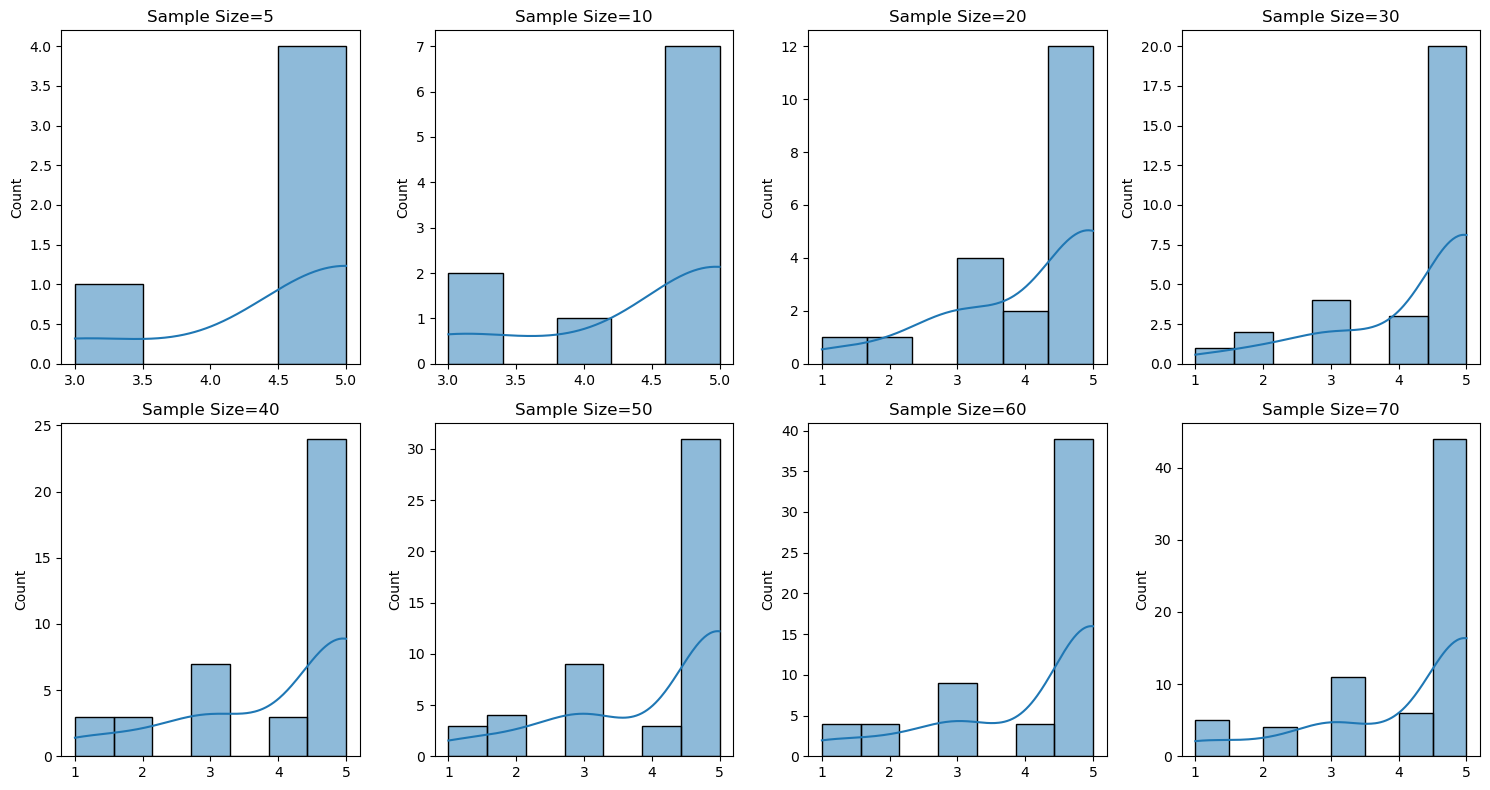

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

num = [5,10,20,30,40,50,60,70]

data_s = []
data_s_mean = []

fig, ax = plt.subplots(2,4,figsize=(15,8))

for i in num:
    sample_df = population_df.sample(n=i, random_state=42, replace=True)
    data_s.append(sample_df['review_score'].tolist())
    data_s_mean.append(sample_df['review_score'].mean())
    
k = 0
for i in range(2):
    for j in range(4):
        sns.histplot(data_s[k], kde=True, ax=ax[i,j])
        ax[i,j].set_title("Sample Size=" + str(len(data_s[k])))
        k += 1

plt.tight_layout()
plt.show()

In [81]:
sample_df = population_df.sample(n=30, random_state=42, replace=True)

print("Sample mean:", round(sample_df["review_score"].mean(), 2))
print("Population mean:", round(population_df["review_score"].mean(), 2))

print("Sample skewness:", round(sample_df["review_score"].skew(), 2))
print("Population skewness:", round(population_df["review_score"].skew(), 2))

print("Sample kurtosis:", round(sample_df["review_score"].kurtosis(), 2))
print("Population kurtosis:", round(population_df["review_score"].kurtosis(), 2))

Sample mean: 4.3
Population mean: 4.09
Sample skewness: -1.52
Population skewness: -1.36
Sample kurtosis: 1.3
Population kurtosis: 0.51


In [82]:
import pandas as pd

sample_df = pd.DataFrame()

for i in range(0,10):
    sample_df["sample"+str(i)] = population_df['review_score'].sample(n=30, random_state=i).reset_index(drop=True)

sample_df

,sample0,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9
0,1.0,5.0,5.0,1.0,4.0,5.0,5.0,1.0,5.0,5.0
1,4.0,3.0,1.0,3.0,1.0,5.0,4.0,1.0,5.0,4.0
2,4.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,3.0,4.0
3,3.0,4.0,5.0,5.0,4.0,5.0,1.0,5.0,5.0,1.0
4,1.0,2.0,5.0,5.0,5.0,5.0,1.0,3.0,5.0,5.0
5,2.0,5.0,4.0,5.0,5.0,1.0,5.0,3.0,5.0,5.0
6,5.0,5.0,4.0,5.0,3.0,4.0,5.0,5.0,5.0,4.0
7,5.0,4.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0
8,5.0,1.0,5.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0
9,5.0,1.0,4.0,4.0,3.0,4.0,1.0,1.0,5.0,5.0


In [83]:
c_names = sample_df.columns
c_mean = []

for i in c_names:
    c_mean.append(sample_df[i].mean())

means = pd.DataFrame()
means.insert(0,"Sample_Name",c_names)
means.insert(1,"Mean",c_mean)

means

,Sample_Name,Mean
0,sample0,4.000000
1,sample1,4.100000
2,sample2,4.200000
3,sample3,4.166667
4,sample4,3.900000
5,sample5,4.166667
6,sample6,4.266667
7,sample7,3.933333
8,sample8,4.200000
9,sample9,4.266667


In [84]:
means_std = means['Mean'].std()
means_std

0.13259052346823386

In [85]:
import math

population_df['review_score'].std() / math.sqrt(30)

0.24553612356354734

In [86]:
from scipy import stats
import math

# Population (all customers)
population = product_order_item_df['review_score'].dropna()

# Sample (n = 30)
sample = population.sample(n=30, random_state=42)


# Statistics
mean_sample = sample.mean()
std_pop = population.std()
n = 30

# Hypothesis value (benchmark)
mu = 4   # business target rating


# Standard Error
se = std_pop / math.sqrt(n)


# Z-score
z_score = (mean_sample - mu) / se


# P-value (Right-tailed test)
p_value = 1 - stats.norm.cdf(z_score)


# Critical Z value
alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha)


# Output
print(f"Sample Mean: {mean_sample:.2f}")
print(f"Population Std Dev: {std_pop:.2f}")
print(f"Z-score: {z_score:.4f}")
print(f"Critical Z: {z_critical:.4f}")
print(f"P-value: {p_value:.4f}")


# Decision
if p_value < alpha:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: Average customer rating is greater than 4 (customers are satisfied)")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: Average customer rating is not significantly greater than 4")

Sample Mean: 3.97
Population Std Dev: 1.34
Z-score: -0.1358
Critical Z: 1.6449
P-value: 0.5540

Result: Fail to Reject Null Hypothesis
Conclusion: Average customer rating is not significantly greater than 4


In [87]:
# Create a new column for high ratings
product_order_item_df['high_rating'] = product_order_item_df['review_score'] >= 4


# Calculate probability
prob_high_rating = product_order_item_df['high_rating'].sum() / len(product_order_item_df)


# Output
print("Probability of high rating (≥ 4):", round(prob_high_rating, 3))

Probability of high rating (≥ 4): 0.77


In [88]:
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(product_order_item_df['gender'], product_order_item_df['review_score'])

# Apply Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", round(chi2, 2))
print("P-value:", round(p, 4))

alpha = 0.05

if p < alpha:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: Gender and review score are related")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: Gender and review score are independent")

Chi-square value: 20.18
P-value: 0.0005

Result: Reject Null Hypothesis
Conclusion: Gender and review score are related


# delivery analysis

In [89]:
import pandas as pd

# Population data (delivery time)
population_df = product_order_item_df[['delivery_time']].dropna()

# Sample data (n = 30)
sample_df = population_df.sample(n=30, random_state=42)

In [90]:
from scipy.stats import skew, kurtosis

print("SUMMARY STATISTICS OF POPULATION")
print(population_df['delivery_time'].describe().round(2))

print("Skewness:", round(skew(population_df['delivery_time']), 2))
print("Kurtosis:", round(kurtosis(population_df['delivery_time']), 2))
print("Median:", population_df['delivery_time'].median())
print("Mode:", population_df['delivery_time'].mode()[0])

SUMMARY STATISTICS OF POPULATION
count    33050.00
mean        72.04
std         60.37
min          1.00
25%         10.00
50%         63.00
75%        122.00
max        318.00
Name: delivery_time, dtype: float64
Skewness: 0.69
Kurtosis: -0.39
Median: 63.0
Mode: 5


In [91]:
print("\nSUMMARY STATISTICS OF SAMPLE DATA")
print(sample_df['delivery_time'].describe().round(2))

print("Skewness:", round(skew(sample_df['delivery_time']), 2))
print("Kurtosis:", round(kurtosis(sample_df['delivery_time']), 2))
print("Median:", sample_df['delivery_time'].median())
print("Mode:", sample_df['delivery_time'].mode()[0])


SUMMARY STATISTICS OF SAMPLE DATA
count     30.00
mean      91.27
std       53.55
min        4.00
25%       43.50
50%       95.00
75%      123.50
max      185.00
Name: delivery_time, dtype: float64
Skewness: 0.17
Kurtosis: -0.84
Median: 95.0
Mode: 36


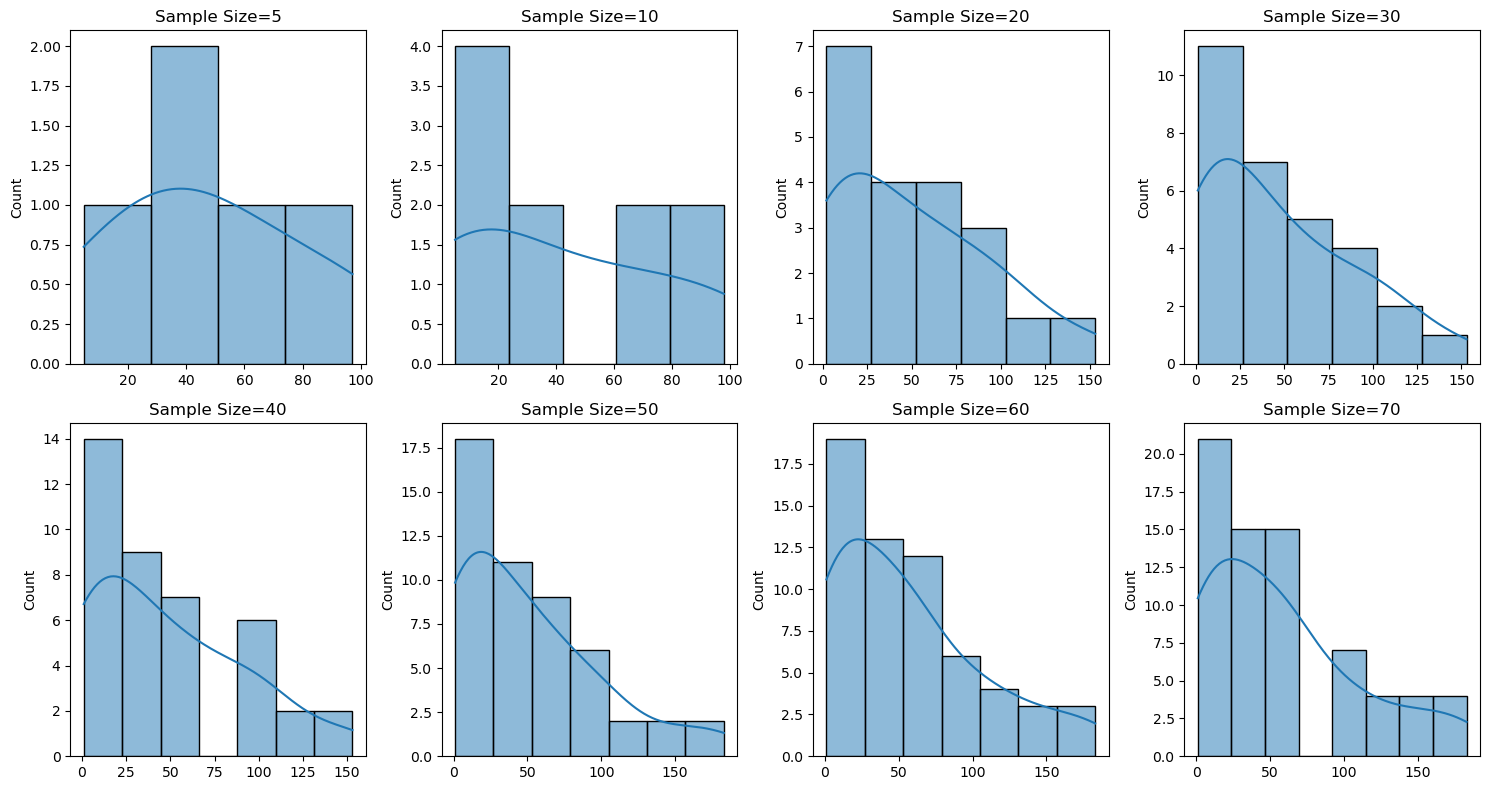

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

num = [5,10,20,30,40,50,60,70]

data_s = []
data_s_mean = []

fig, ax = plt.subplots(2,4,figsize=(15,8))

k = 0

for i in num:
    sample_df = population_df.sample(n=i, random_state=42, replace=True)
    data_s.append(sample_df['delivery_time'].tolist())
    data_s_mean.append(sample_df['delivery_time'].mean())

k = 0

for i in range(2):
    for j in range(4):
        sns.histplot(data_s[k], kde=True, ax=ax[i,j])
        ax[i,j].set_title("Sample Size=" + str(len(data_s[k])))
        k += 1

plt.tight_layout()
plt.show()

In [93]:
# Sample of size 30
sample_df = population_df.sample(n=30, random_state=42, replace=True)

print("-----Mean Value------")
print("Sample mean:", round(sample_df["delivery_time"].mean(), 2))
print("Population mean:", round(population_df["delivery_time"].mean(), 2))

print("-----Skewness------")
print("Sample Skewness:", round(sample_df["delivery_time"].skew(), 2))
print("Population Skewness:", round(population_df["delivery_time"].skew(), 2))

print("-----Kurtosis------")
print("Sample Kurtosis:", round(sample_df["delivery_time"].kurtosis(), 2))
print("Population Kurtosis:", round(population_df["delivery_time"].kurtosis(), 2))

-----Mean Value------
Sample mean: 46.8
Population mean: 72.04
-----Skewness------
Sample Skewness: 0.83
Population Skewness: 0.69
-----Kurtosis------
Sample Kurtosis: -0.23
Population Kurtosis: -0.39


In [94]:
import pandas as pd

sample_df = pd.DataFrame()

for i in range(0,10):
    sample_df["sample"+str(i)] = population_df['delivery_time'].sample(n=30, random_state=i).reset_index(drop=True)

sample_df

,sample0,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9
0,151,61,5,9,9,66,33,3,95,7
1,6,178,8,59,5,5,66,38,120,89
2,31,4,33,30,154,36,35,65,8,34
3,147,3,35,151,67,66,67,65,5,6
4,59,63,34,36,62,212,6,59,96,34
5,7,127,61,185,8,153,178,153,39,36
6,123,30,36,64,4,5,180,181,92,92
7,212,210,63,94,66,9,37,36,3,7
8,67,210,94,210,66,37,32,67,89,37
9,151,151,7,239,240,5,126,10,7,211


In [95]:
c_names = sample_df.columns
c_mean = []

for i in c_names:
    c_mean.append(sample_df[i].mean())

means = pd.DataFrame()
means.insert(0,"C_name",c_names)
means.insert(1,"mean",c_mean)

means

,C_name,mean
0,sample0,70.200000
1,sample1,86.200000
2,sample2,57.900000
3,sample3,69.433333
4,sample4,73.633333
5,sample5,57.833333
6,sample6,59.433333
7,sample7,64.000000
8,sample8,70.566667
9,sample9,53.466667


In [96]:
means_std = means['mean'].std()
means_std

9.731899945191067

In [97]:
import math

population_df['delivery_time'].std() / math.sqrt(30)

11.022761479686688

In [98]:
from scipy import stats
import math

# Population
population = product_order_item_df['delivery_time'].dropna()

# Sample (n = 30)
sample = population.sample(n=30, random_state=42)

# Statistics
mean_sample = sample.mean()
std_pop = population.std()
n = 30
mu = 5   # target delivery time

# Standard Error
se = std_pop / math.sqrt(n)

# Z-score
z_score = (mean_sample - mu) / se

# P-value (left-tailed)
p_value = stats.norm.cdf(z_score)

# Critical Z
alpha = 0.05
z_critical = stats.norm.ppf(alpha)

# Output
print(f"Sample Mean: {mean_sample:.2f}")
print(f"Population Std Dev: {std_pop:.2f}")
print(f"Z-score: {z_score:.4f}")
print(f"Critical Z: {z_critical:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
if p_value < alpha:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: Delivery time is significantly less than 5 days")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: Delivery time is not significantly less than 5 days")

Sample Mean: 91.27
Population Std Dev: 60.37
Z-score: 7.8262
Critical Z: -1.6449
P-value: 1.0000

Result: Fail to Reject Null Hypothesis
Conclusion: Delivery time is not significantly less than 5 days


In [99]:
# Create a column for fast delivery
product_order_item_df['fast_delivery'] = product_order_item_df['delivery_time'] <= 5


# Calculate probability
prob_fast = product_order_item_df['fast_delivery'].sum() / len(product_order_item_df)


# Output
print("Probability of delivery within 5 days:", round(prob_fast, 3))

Probability of delivery within 80 minutes: 0.115


In [102]:
import pandas as pd
from scipy.stats import chi2_contingency

product_order_item_df['fast_delivery'] = product_order_item_df['delivery_time'] <= 5   # True / False


print("Payment Type Distribution:")
print(product_order_item_df['payment_type'].value_counts())

print("\nFast Delivery Distribution:")
print(product_order_item_df['fast_delivery'].value_counts())


table = pd.crosstab(product_order_item_df['payment_type'], product_order_item_df['fast_delivery'])

print("\nContingency Table:")
print(table)


chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square value:", round(chi2, 2))
print("P-value:", round(p, 4))

alpha = 0.05

if p < alpha:
    print("\nResult: Reject Null Hypothesis")
    print("Conclusion: Payment type and delivery speed are related")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Conclusion: Payment type and delivery speed are independent")

Payment Type Distribution:
UPI                 18343
Credit Card          8198
Net Banking          4861
Cash on Delivery     1648
Name: payment_type, dtype: int64

Fast Delivery Distribution:
False    29233
True      3817
Name: fast_delivery, dtype: int64

Contingency Table:
fast_delivery     False  True
payment_type                 
Cash on Delivery   1442   206
Credit Card        7219   979
Net Banking        4287   574
UPI               16285  2058

Chi-square value: 4.97
P-value: 0.1742

Result: Fail to Reject Null Hypothesis
Conclusion: Payment type and delivery speed are independent


In [103]:
import numpy as np
drop_cols = [
    'order_item_id','order_id','product_id',
    'customer_id','review_id','customer_zip_code','order_Year','Order_Month','order_day_of_week'
]



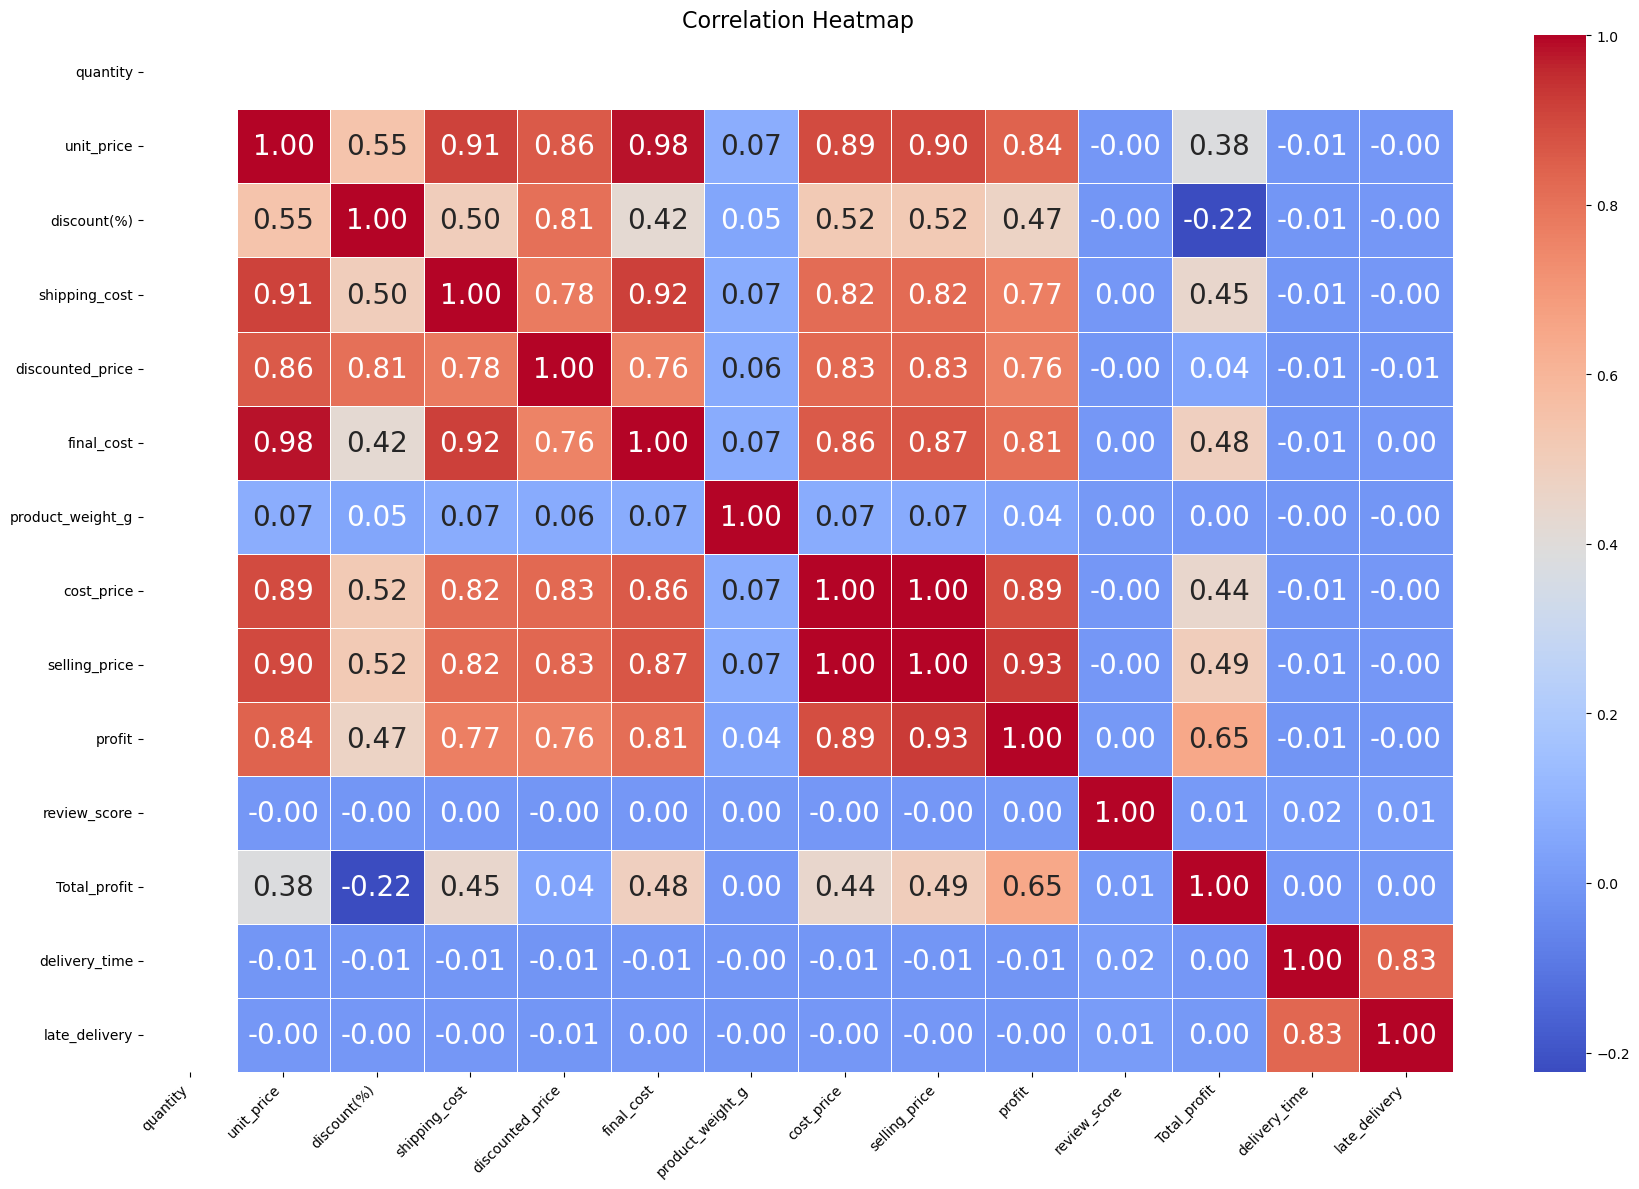

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = product_order_item_df.drop(columns=drop_cols).select_dtypes(include=[np.number])

# Increase figure size
plt.figure(figsize=(18, 12))

# Draw heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,           # show values
    fmt=".2f",            # 2 decimal points
    cmap="coolwarm",      # better color contrast
    linewidths=0.5,
    annot_kws={"size": 20} # smaller text for clarity
)

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Title
plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

In [105]:
import numpy as np
numeric_df = product_order_item_df.drop(columns=drop_cols).select_dtypes(include=[np.number])
print(numeric_df.columns)

Index(['quantity', 'unit_price', 'discount(%)', 'shipping_cost',
       'discounted_price', 'final_cost', 'product_weight_g', 'cost_price',
       'selling_price', 'profit', 'review_score', 'Total_profit',
       'delivery_time', 'late_delivery'],
      dtype='object')


In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scale only numeric columns
product_order_item_df[numeric_df.columns] = scaler.fit_transform(
    product_order_item_df[numeric_df.columns]
)

In [107]:
product_order_item_df[numeric_df.columns].head()

,quantity,unit_price,discount(%),shipping_cost,discounted_price,final_cost,product_weight_g,cost_price,selling_price,profit,review_score,Total_profit,delivery_time,late_delivery
0,0.0,0.385923,-0.777314,0.402931,-0.366975,0.619286,0.044357,0.147934,0.200359,0.395711,-2.295461,1.188984,0.794390,1.034482
5,0.0,0.516262,1.467342,0.960136,0.849450,0.432803,2.193518,0.319659,0.293455,0.159531,-2.295461,-0.452324,-1.110428,-0.966667
8,0.0,0.516262,-0.342090,-0.271441,-0.107207,0.601730,2.193518,0.319659,0.293455,0.159531,0.678878,0.216299,-1.060737,-0.966667
10,0.0,2.064334,1.919700,2.067947,2.712800,1.742794,-0.623870,1.423885,1.399173,1.169403,-0.808291,-1.075055,-1.093864,-0.966667
19,0.0,-0.869456,0.195942,-0.813381,-0.548948,-0.924961,2.193518,-0.656773,-0.696301,-0.793331,0.678878,-0.690828,-0.563828,-0.966667


In [108]:
scale_cols = [
    col for col in numeric_df.columns
    if col not in ['Total_profit', 'late_delivery']
]

product_order_item_df[scale_cols] = scaler.fit_transform(
    product_order_item_df[scale_cols]
)

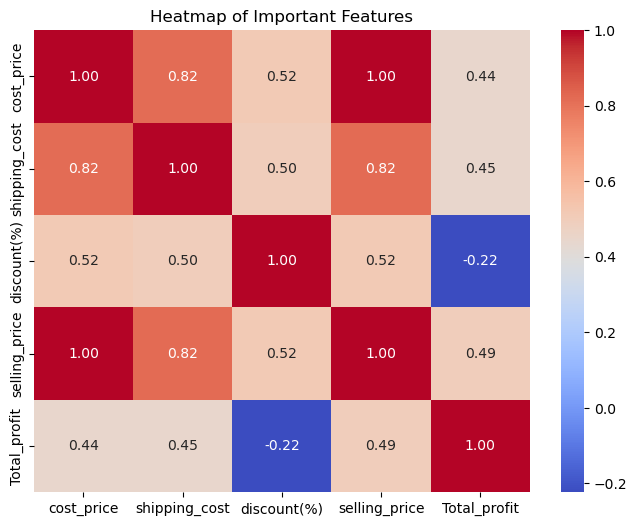

In [109]:
# HEATMAP FOR SELECTED IMPORTANT FEATURES

import matplotlib.pyplot as plt
import seaborn as sns

important_features = ['cost_price','shipping_cost','discount(%)','selling_price','Total_profit']

plt.figure(figsize=(8,6))

sns.heatmap(product_order_item_df[important_features].corr(),annot=True,cmap='coolwarm',fmt=".2f")

plt.title("Heatmap of Important Features")

plt.show()

# LInear Regreesion

In [110]:
# Predicting Total Profit Based on Pricing and Operational Factors Using Linear Regression.

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [112]:
# 1. SELECT FEATURES & TARGET

features = [
        'cost_price',
        'shipping_cost',
        'discount(%)',
        'selling_price'
]

X = product_order_item_df[features]

y = product_order_item_df['Total_profit']


In [113]:
# 2. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)


In [114]:
# 3. FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [115]:
# 4. BUILD LINEAR REGRESSION MODEL
model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [116]:
# 5. PREDICTIONS

y_pred = model.predict(X_test_scaled)



In [117]:
# 6. INTERCEPT & SLOPES

print("Intercept:")
print(model.intercept_)

print("\nSlopes / Coefficients:")

coeff_df = pd.DataFrame({
    'Feature': features,
    'Slope': model.coef_
})

print(coeff_df)


Intercept:
-0.002763905338269074

Slopes / Coefficients:
         Feature     Slope
0     cost_price -5.309326
1  shipping_cost  0.240760
2    discount(%) -0.662546
3  selling_price  5.923834


In [118]:
# 7. MODEL EVALUATION
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.821519384520373
MAE : 0.29843577451434244
MSE : 0.17421892192243285
RMSE : 0.41739540237337647


In [119]:
# CALCULATE RESIDUALS

def calculate_residuals(model, features, label):
    predictions = model.predict(features)
    
    df_results = pd.DataFrame({
        'Actual': label,
        'Predicted': predictions
    })
    
    df_results['Residuals'] = (
        df_results['Actual'] - df_results['Predicted']
    )
    
    return df_results

In [120]:
# HOMOSCEDASTICITY ASSUMPTION

def homoscedasticity_assumption(model, features, label):
    
    # Calculate residuals
    df_results = calculate_residuals(model, features, label)
    
    # Residual Plot
    plt.figure(figsize=(12,6))
    
    plt.scatter(
        x=df_results.index,
        y=df_results['Residuals'],
        alpha=0.5
    )
    
    # Horizontal line at 0
    plt.axhline(y=0, color='darkorange', linestyle='--')
    
    plt.title('Residual Plot')
    plt.xlabel('Index')
    plt.ylabel('Residuals')
    
    plt.grid(True)
    plt.show()

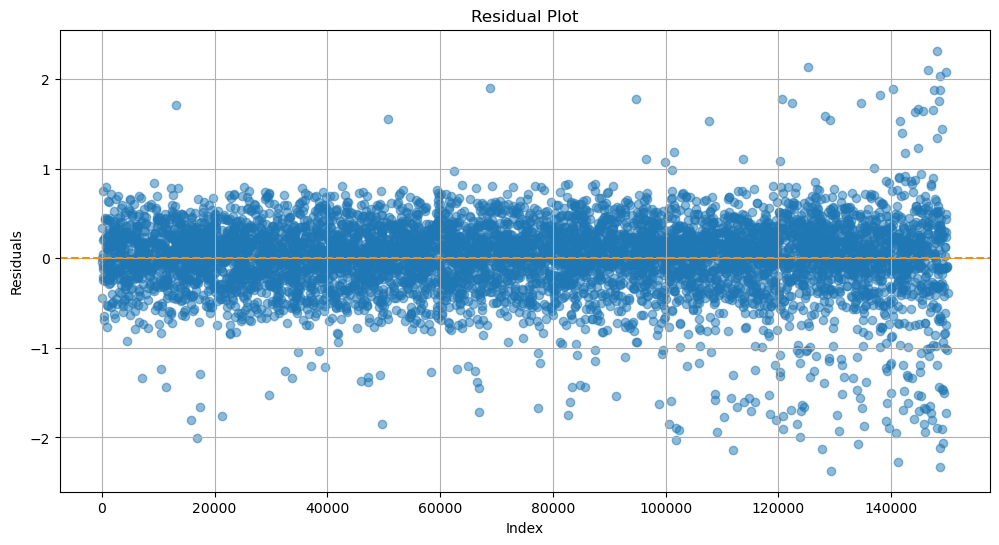

In [121]:
homoscedasticity_assumption(model,X_test_scaled,y_test)

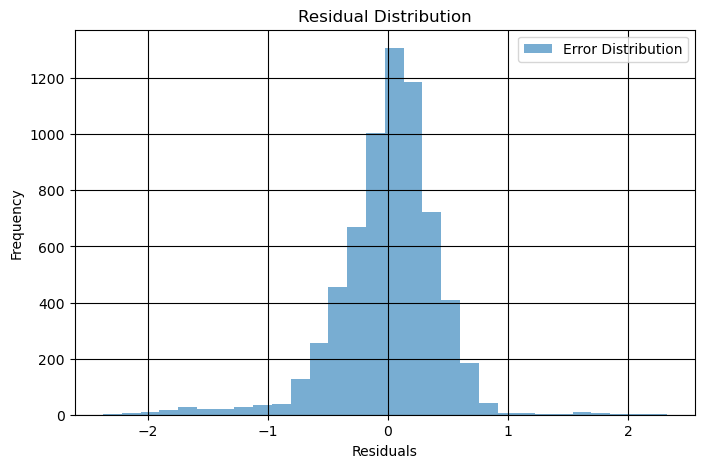

In [122]:
# Error Normality curve

df_results = calculate_residuals( model,X_test_scaled,y_test)

plt.figure(figsize=(8,5))

plt.hist(df_results['Residuals'],bins=30,alpha=0.6,label="Error Distribution")

plt.legend()

plt.grid(True, color='black')

plt.title("Residual Distribution")

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

# Logistic regression

In [124]:
# LOGISTIC REGRESSION
# LATE DELIVERY PREDICTION
 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
w
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score



In [125]:
# 2. CREATE COPY OF DATA

df = product_order_item_df.copy()

# 3. HANDLE MISSING VALUES

df['review_score'] = df['review_score'].fillna(
    df['review_score'].median()
)



In [126]:
# 4. CREATE TARGET VARIABLE
# 1 = Late Delivery
# 0 = On-Time Delivery

median_value = df['delivery_time'].median()

df['late_delivery'] = df['delivery_time'].apply(
    lambda x: 1 if x > median_value else 0
)

print(df['late_delivery'].value_counts())



0    17085
1    15965
Name: late_delivery, dtype: int64


In [127]:
# 5. SELECT ONLY NUMERICAL FEATURES

X = df[[
    'shipping_cost',
    'quantity',
    'discount(%)',
    'Total_profit',
    'review_score'
]]

# TARGET VARIABLE
y = df['late_delivery']



In [139]:
# 6. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

# 3. FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [152]:
# 8. BUILD LOGISTIC REGRESSION MODEL

model = LogisticRegression(
    random_state=42,
    max_iter=2000)

model.fit(X_train_scaled, y_train)

print("\nModel Trained Successfully")



Model Trained Successfully


In [154]:

# 9. PREDICTIONS
pred = model.predict(X_test_scaled)

print("\nPredictions Completed")



Predictions Completed


In [155]:
# 10. ACCURACY SCORE

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy Score:")
print(accuracy)




Accuracy Score:
0.5195158850226929


In [156]:
# 11. CONFUSION MATRIX

cm = confusion_matrix(y_test, pred)

print("\nConfusion Matrix:\n")
print(cm)




Confusion Matrix:

[[3433    0]
 [3176    1]]


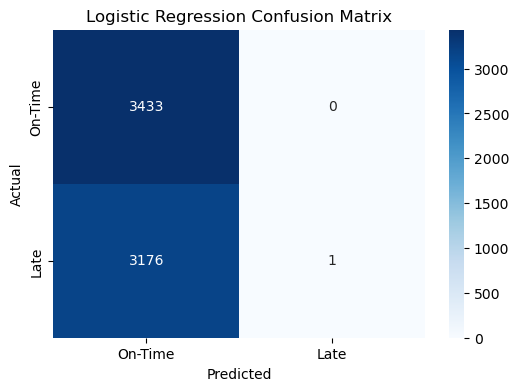

In [157]:
# 12. CONFUSION MATRIX HEATMAP

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['On-Time', 'Late'],
    yticklabels=['On-Time', 'Late']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()



In [158]:
# 
# 13. CLASSIFICATION REPORT

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred,
        target_names=['On-Time', 'Late']
    )
)




Classification Report:

              precision    recall  f1-score   support

     On-Time       0.52      1.00      0.68      3433
        Late       1.00      0.00      0.00      3177

    accuracy                           0.52      6610
   macro avg       0.76      0.50      0.34      6610
weighted avg       0.75      0.52      0.36      6610



In [159]:
# 14. ROC-AUC SCORE

y_pred_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

auc_score = roc_auc_score(
    y_test,
    y_pred_proba
)

print("\nROC-AUC Score:")
print(auc_score)




ROC-AUC Score:
0.5040428120811898


C:\Users\Nani\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


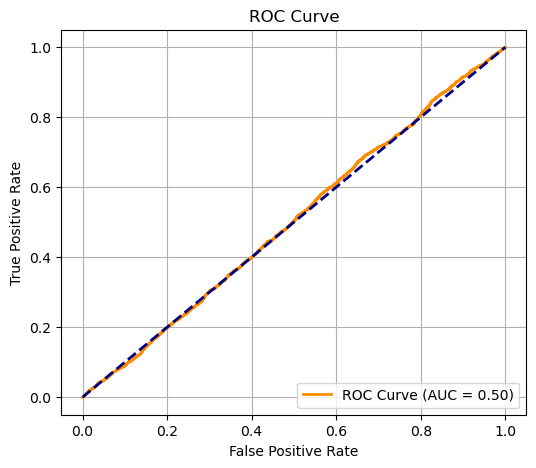

In [160]:
# 15. ROC CURVE

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label='ROC Curve (AUC = %0.2f)' % auc_score
)

plt.plot(
    [0,1],
    [0,1],
    color='navy',
    lw=2,
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

# KNN

In [411]:

# KNN CLASSIFICATION
# CUSTOMER SEGMENT PREDICTION

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)



In [412]:
# =========================================
# 2. CREATE COPY OF DATA
# =========================================

df = product_order_item_df.copy()

# =========================================
# 3. HANDLE MISSING VALUES
# =========================================

df['review_score'] = df['review_score'].fillna(
    df['review_score'].median()
)

df = df[df['customer_segment'].notna()]



In [413]:
# =========================================
# 4. ENCODE TARGET VARIABLE
# =========================================

le = LabelEncoder()

df['customer_segment_encoded'] = le.fit_transform(
    df['customer_segment']
)

print(df['customer_segment'].value_counts())



New          16688
Returning    11500
Loyal         4862
Name: customer_segment, dtype: int64


In [414]:
# =========================================
# 5. SELECT ONLY NUMERICAL FEATURES
# =========================================

X = df[[                    
    'unit_price',
    'shipping_cost',
    'profit',
    'Total_profit'
]]

# TARGET VARIABLE
y = df['customer_segment_encoded']



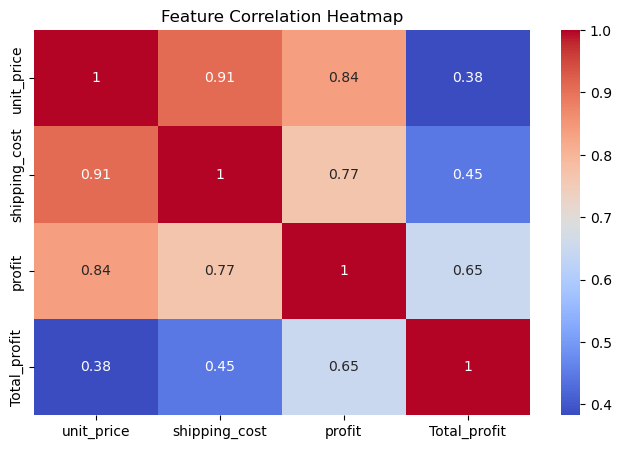

In [416]:
# =========================================
# 6. FEATURE SCALING
# =========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8,5))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()


In [417]:
# =========================================
# 7. TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 23135
Testing Samples: 9915


C:\Users\Nani\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Nani\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims`

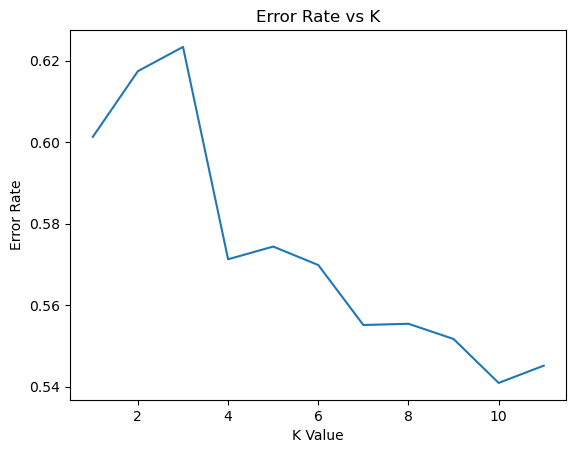

In [418]:
from sklearn import neighbors
import numpy as np
import matplotlib.pyplot as plt

error_rate = []

for i in range(1,12):
    knn = neighbors.KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rate.append(np.mean(y_test != pred))

plt.plot(range(1,12), error_rate)
plt.title("Error Rate vs K")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [419]:
# =========================================
# 8. BUILD KNN MODEL
# =========================================

knn_model = KNeighborsClassifier(
    n_neighbors=10,
     weights='distance'
)

knn_model.fit(X_train, y_train)

print("\nKNN Model Trained Successfully")




KNN Model Trained Successfully


In [420]:
# =========================================
# 9. PREDICTIONS
# =========================================

pred = knn_model.predict(X_test)

print("\nPredictions Completed")




Predictions Completed


In [421]:
# =========================================
# 10. ACCURACY SCORE
# =========================================

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy Score:")
print(accuracy)




Accuracy Score:
0.44064548663640946


In [422]:
# =========================================
# 11. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, pred)

print("\nConfusion Matrix:\n")
print(cm)




Confusion Matrix:

[[  63  973  423]
 [ 211 3333 1462]
 [ 139 2338  973]]


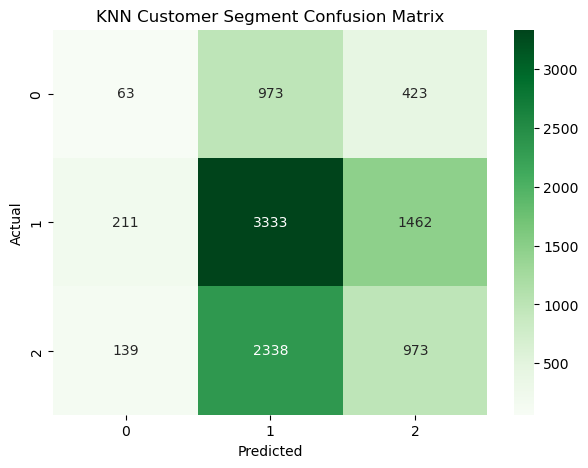

In [423]:
# =========================================
# 12. CONFUSION MATRIX HEATMAP
# =========================================

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("KNN Customer Segment Confusion Matrix")

plt.show()


In [393]:

# =========================================
# 13. CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.15      0.04      0.07      1459
           1       0.50      0.67      0.57      5006
           2       0.34      0.28      0.31      3450

    accuracy                           0.44      9915
   macro avg       0.33      0.33      0.32      9915
weighted avg       0.39      0.44      0.41      9915



# Kmean

In [266]:
order_stats = df[['Total_profit','delivery_time']]

In [267]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(order_stats)

In [268]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

order_stats['cluster'] = kmeans.fit_predict(scaled)

order_stats.head()

C:\Users\Nani\AppData\Local\Temp\ipykernel_320\3799904549.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  order_stats['cluster'] = kmeans.fit_predict(scaled)


,Total_profit,delivery_time,cluster
0,1.188984,0.794390,1
5,-0.452324,-1.110428,0
8,0.216299,-1.060737,3
10,-1.075055,-1.093864,0
19,-0.690828,-0.563828,0


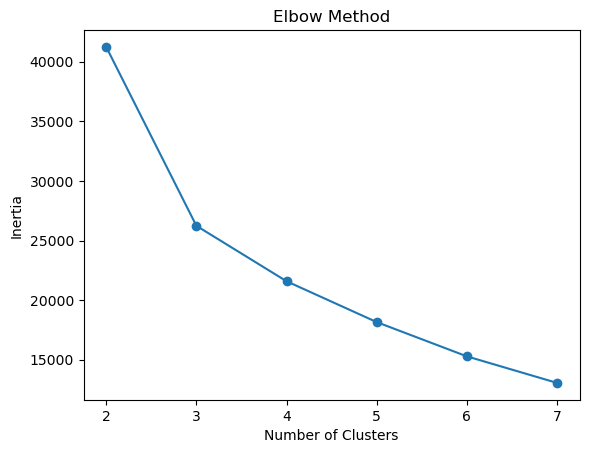

In [207]:
import matplotlib.pyplot as plt

inertia = []

for i in range(2,8):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(scaled)
    
    inertia.append(kmeans.inertia_)

plt.plot(range(2,8), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [208]:
cluster_labels = {
    0: "High Value - Fast Delivery",
    1: "High Value - Slow Delivery",
    2: "Low Value - Fast Delivery",
    3: "Low Value - Slow Delivery"
}

order_stats["cluster_type"] = order_stats["cluster"].map(cluster_labels)

order_stats.head()

C:\Users\Nani\AppData\Local\Temp\ipykernel_320\1899747798.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  order_stats["cluster_type"] = order_stats["cluster"].map(cluster_labels)


,Total_profit,delivery_time,cluster,cluster_type
0,1.188984,0.794390,1,High Value - Slow Delivery
5,-0.452324,-1.110428,0,High Value - Fast Delivery
8,0.216299,-1.060737,3,Low Value - Slow Delivery
10,-1.075055,-1.093864,0,High Value - Fast Delivery
19,-0.690828,-0.563828,0,High Value - Fast Delivery


In [209]:
df_summary = order_stats.groupby('cluster_type')[[
    'Total_profit','delivery_time'
]].mean().sort_values(by='Total_profit', ascending=False)

df_summary

,Total_profit,delivery_time
cluster_type,,
Low Value - Fast Delivery,2.562461,0.151482
Low Value - Slow Delivery,0.606592,-0.608692
High Value - Slow Delivery,-0.220985,1.130338
High Value - Fast Delivery,-0.603991,-0.697044


<AxesSubplot:xlabel='delivery_time', ylabel='Total_profit'>

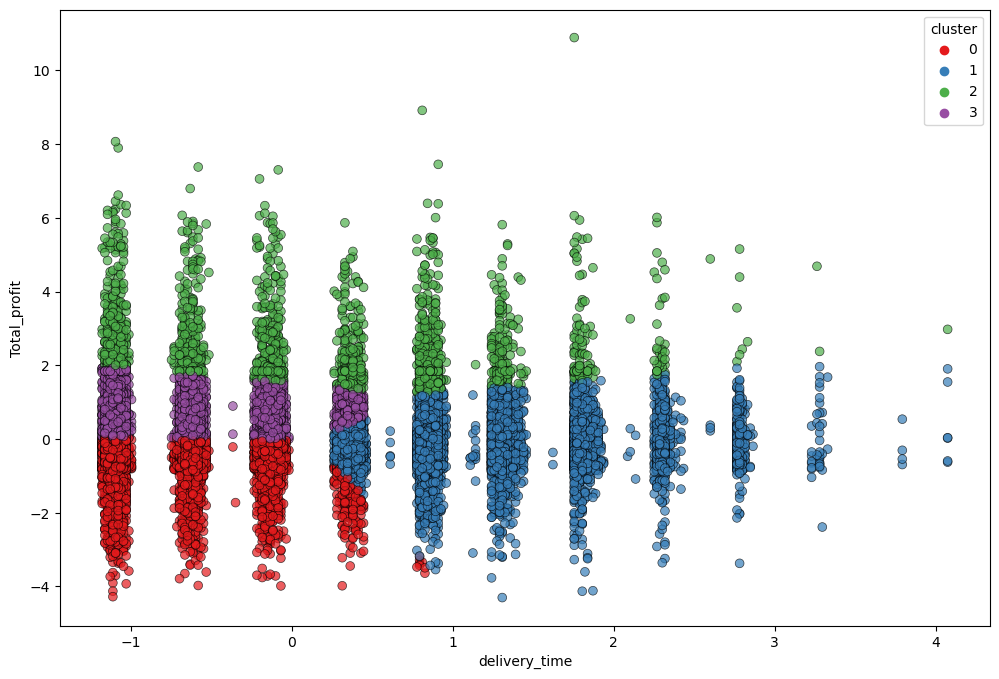

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# K-MEANS CLUSTER VISUALIZATION
# =========================================

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=order_stats,
    x="delivery_time",
    y="Total_profit",
    hue="cluster",
    palette="Set1",
    s=40,              # Bigger points
    alpha=0.7,         # Better visibility
    edgecolor='black'  # Point borders
)


In [429]:
# =========================================
# KNN CLASSIFICATION
# CUSTOMER SEGMENT PREDICTION
# =========================================

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# 2. CREATE COPY OF DATA

df = product_order_item_df.copy()

# 3. HANDLE MISSING VALUES

df['review_score'] = df['review_score'].fillna(
    df['review_score'].median()
)

#
# 4. HANDLE OUTLIERS


df['profit'] = df['profit'].clip(
    lower=df['profit'].quantile(0.01),
    upper=df['profit'].quantile(0.99)
)

df['shipping_cost'] = df['shipping_cost'].clip(
    lower=df['shipping_cost'].quantile(0.01),
    upper=df['shipping_cost'].quantile(0.99)
)

df['Total_profit'] = df['Total_profit'].clip(
    lower=df['Total_profit'].quantile(0.01),
    upper=df['Total_profit'].quantile(0.99)
)


In [430]:

# =========================================
# 5. CREATE BALANCED CUSTOMER SEGMENTS
# =========================================

df['customer_segment'] = pd.qcut(
    df['Total_profit'],
    q=3,
    labels=['Low','Medium','High']
)

print(df['customer_segment'].value_counts())



Low       11017
High      11017
Medium    11016
Name: customer_segment, dtype: int64


In [431]:
# =========================================
# 6. ENCODE TARGET VARIABLE
# =========================================

le = LabelEncoder()

df['customer_segment_encoded'] = le.fit_transform(
    df['customer_segment']
)



In [432]:
# =========================================
# 7. SELECT FEATURES
# =========================================

X = df[
[
    'unit_price',
    'shipping_cost',
    'profit'
]
]

# TARGET VARIABLE

y = df['customer_segment_encoded']

# =========================================
# 8. FEATURE SCALING
# =========================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)



In [433]:
# =========================================
# 9. TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])



Training Samples: 23135
Testing Samples: 9915


In [434]:
# =========================================
# 10. FIND BEST K VALUE
# =========================================

accuracy_scores = []

for k in range(1,21):

    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='manhattan'
    )

    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    acc = accuracy_score(y_test, pred_k)

    accuracy_scores.append(acc)

    print("K =", k, "Accuracy =", acc)



K = 1 Accuracy = 0.6744326777609683
K = 2 Accuracy = 0.6741301059001513
K = 3 Accuracy = 0.686535552193646
K = 4 Accuracy = 0.6928895612708018
K = 5 Accuracy = 0.6982349974785679
K = 6 Accuracy = 0.7016641452344932
K = 7 Accuracy = 0.7074130105900152
K = 8 Accuracy = 0.708421583459405
K = 9 Accuracy = 0.7121533030761472
K = 10 Accuracy = 0.7107413010590015
K = 11 Accuracy = 0.7114473020675743
K = 12 Accuracy = 0.7122541603630862
K = 13 Accuracy = 0.713262733232476
K = 14 Accuracy = 0.7144730206757438
K = 15 Accuracy = 0.7152798789712557
K = 16 Accuracy = 0.7148764498234997
K = 17 Accuracy = 0.7162884518406455
K = 18 Accuracy = 0.7167927382753404
K = 19 Accuracy = 0.7182047402924862
K = 20 Accuracy = 0.7179021684316692


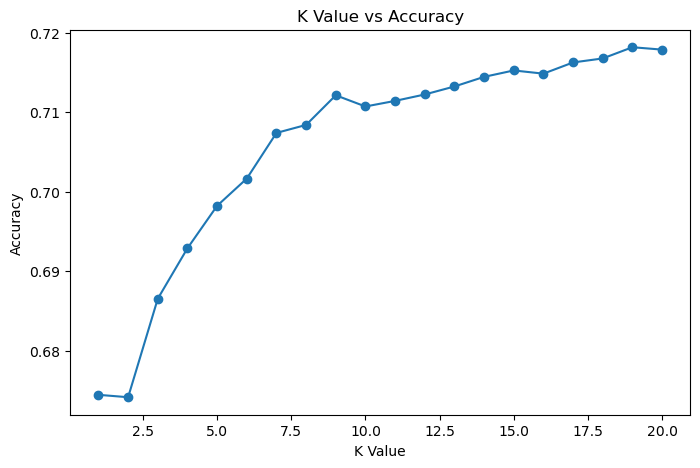

In [435]:
# =========================================
# 11. VISUALIZE K VS ACCURACY
# =========================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("K Value vs Accuracy")

plt.show()



In [436]:
# =========================================
# 12. BUILD FINAL KNN MODEL
# =========================================

knn_model = KNeighborsClassifier(
    n_neighbors=20,
    weights='distance',
    metric='manhattan'
)

knn_model.fit(X_train, y_train)

print("\nKNN Model Trained Successfully")




KNN Model Trained Successfully


In [437]:
# =========================================
# 13. PREDICTIONS
# =========================================

pred = knn_model.predict(X_test)

print("\nPredictions Completed")

# =========================================
# 14. ACCURACY SCORE
# =========================================

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy Score:")
print(accuracy)




Predictions Completed

Accuracy Score:
0.7179021684316692


In [438]:
# =========================================
# 15. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, pred)

print("\nConfusion Matrix:\n")
print(cm)




Confusion Matrix:

[[2657  197  451]
 [ 363 2386  556]
 [ 681  549 2075]]


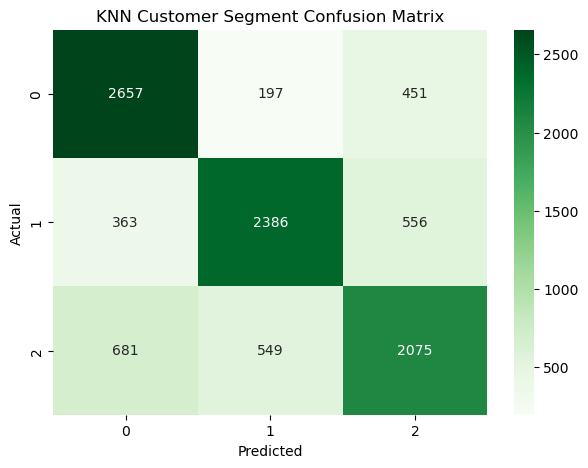

In [439]:
# =========================================
# 16. CONFUSION MATRIX HEATMAP
# =========================================

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("KNN Customer Segment Confusion Matrix")

plt.show()



In [440]:
# =========================================
# 17. CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred
    )
)




Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.80      0.76      3305
           1       0.76      0.72      0.74      3305
           2       0.67      0.63      0.65      3305

    accuracy                           0.72      9915
   macro avg       0.72      0.72      0.72      9915
weighted avg       0.72      0.72      0.72      9915



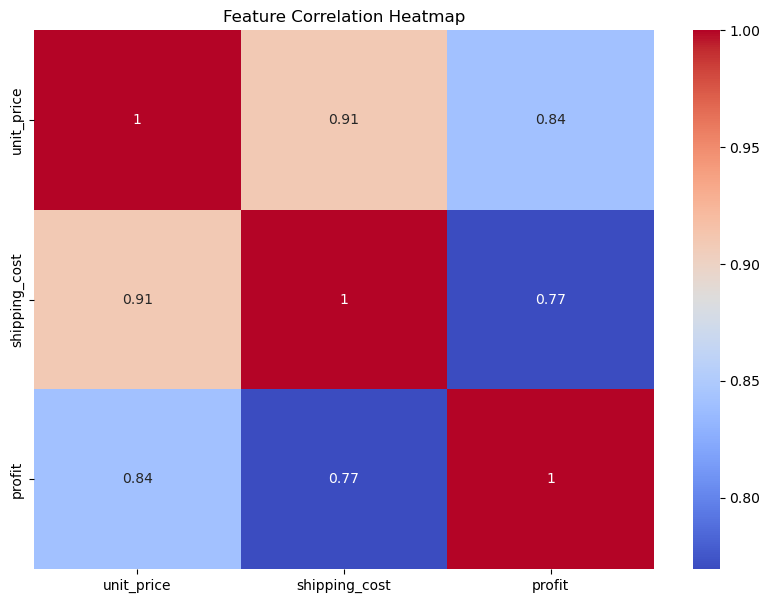

In [441]:
# =========================================
# 18. FEATURE CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(10,7))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [443]:
# LOGISTIC REGRESSION
# LATE DELIVERY PREDICTION
 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score



In [444]:
# =========================================
# 2. CREATE COPY OF DATA
# =========================================

df = product_order_item_df.copy()

# =========================================
# 3. HANDLE MISSING VALUES
# =========================================

df['review_score'] = df['review_score'].fillna(
    df['review_score'].median()
)

# =========================================
# 4. HANDLE OUTLIERS
# =========================================

df['shipping_cost'] = df['shipping_cost'].clip(
    lower=df['shipping_cost'].quantile(0.01),
    upper=df['shipping_cost'].quantile(0.99)
)



In [445]:
# =========================================
# 5. CREATE TARGET VARIABLE
# =========================================
# 1 = Late Delivery
# 0 = On-Time Delivery
median_value = df['delivery_time'].median()

df['late_delivery'] = df['delivery_time'].apply(
    lambda x: 1 if x > median_value else 0
)
# =========================================
# 6. SELECT FEATURES
# =========================================

X = df[
['shipping_cost',
    'unit_price',
    'discount(%)'
]
]

# TARGET VARIABLE

y = df['late_delivery']

# =========================================
# 7. FEATURE SCALING
# =========================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)



In [446]:
# =========================================
# 8. TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])



Training Samples: 26440
Testing Samples: 6610


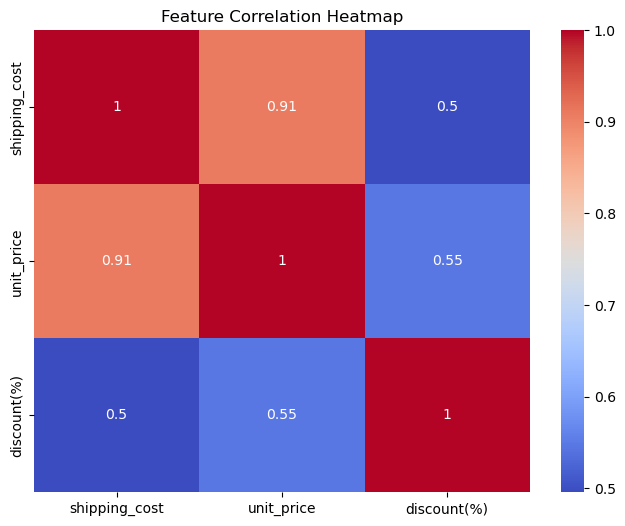

In [447]:
# =========================================
# 9. FEATURE CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()



In [448]:
# =========================================
# 10. BUILD LOGISTIC REGRESSION MODEL
# =========================================

model = LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

print("\nModel Trained Successfully")



Model Trained Successfully


In [449]:

# =========================================
# 11. PREDICTIONS
# =========================================

pred = model.predict(X_test)

print("\nPredictions Completed")

# =========================================
# 12. ACCURACY SCORE
# =========================================

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy Score:")
print(accuracy)



Predictions Completed

Accuracy Score:
0.49198184568835096


In [450]:

# =========================================
# 13. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, pred)

print("\nConfusion Matrix:\n")
print(cm)




Confusion Matrix:

[[1532 1885]
 [1473 1720]]


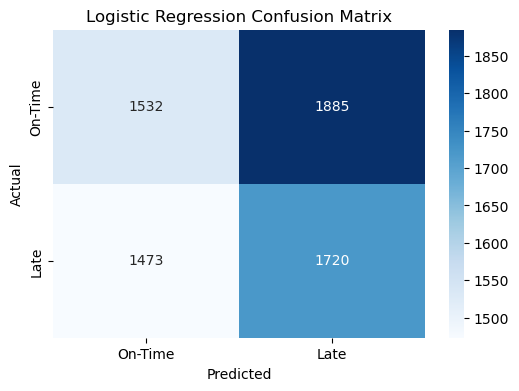

In [451]:
# =========================================
# 14. CONFUSION MATRIX HEATMAP
# =========================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['On-Time', 'Late'],
    yticklabels=['On-Time', 'Late']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()



In [452]:
# =========================================
# 15. CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred,
        target_names=['On-Time', 'Late']
    )
)




Classification Report:

              precision    recall  f1-score   support

     On-Time       0.51      0.45      0.48      3417
        Late       0.48      0.54      0.51      3193

    accuracy                           0.49      6610
   macro avg       0.49      0.49      0.49      6610
weighted avg       0.49      0.49      0.49      6610



In [453]:
# =========================================
# 16. ROC-AUC SCORE
# =========================================

y_pred_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

auc_score = roc_auc_score(
    y_test,
    y_pred_proba
)

print("\nROC-AUC Score:")
print(auc_score)




ROC-AUC Score:
0.4890067633131848


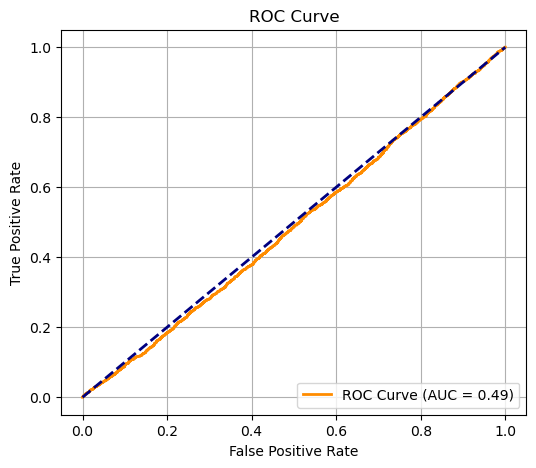

In [454]:
# =========================================
# 17. ROC CURVE
# =========================================

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label='ROC Curve (AUC = %0.2f)' % auc_score
)

plt.plot(
    [0,1],
    [0,1],
    color='navy',
    lw=2,
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()